In [1]:
import instructor
import cohere
from openai import OpenAI
from qdrant_client import QdrantClient, models
from pydantic import BaseModel, Field
from typing import List, Union, Annotated
from jinja2 import Template
from langsmith import traceable, get_current_run_tree

In [2]:

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langgraph.types import Send

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

import openai

from utils.utils import get_tool_descriptions, format_ai_message, display_graph

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from langsmith import traceable

In [3]:
openai_client = OpenAI()
cohere_client = cohere.Client()
qdrant_client = QdrantClient(host="localhost", port=6333)

collection_name = "cm_interventions_hybrid"

## Query Expansion - Parallel

In [ ]:
from operator import add
from pydantic import BaseModel

class ExpandedQuery(BaseModel):
    query: str = Field(description="A semantic search statement derived from the original question")
    top_k: int = Field(description="Number of results to retrieve for this query (1-10), based on how specific or broad it is")

class QueryExpandResponse(BaseModel):
    statements: List[ExpandedQuery]

class State(BaseModel):
    expanded_query: List[ExpandedQuery] = []
    retrieved_contexts: Annotated[List[str], add] = []
    initial_query: str = ""
    query: str = ""
    answer: str = ""
    top_k: int = 5
    question_relevant: bool = False


In [5]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module for a maintenance assistant. Your job is to rewrite a technician's query into distinct semantic statements to search past intervention logs.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should focus on a specific machine, component, or symptom.
    - Use technical maintenance terminology (e.g., 'abnormal vibration', 'hydraulic leak').
    - Do not produce redundant statements.
    - For each statement, also assign a top_k (1-10): use higher values for broad queries, lower for specific ones.

    ## Examples

    Question: "The conveyor motor is smoking and making a grinding noise"
    Statements:
    - query: "Conveyor motor overheating and smoke symptom", top_k: 3
    - query: "Motor bearing grinding noise", top_k: 3

    Question: "Check history of machine 307 valve issues"
    Statements:
    - query: "Machine 307 maintenance history", top_k: 8
    - query: "Hydraulic valve failure logs", top_k: 5

    Question: "How to fix a sensor error on line 4?"
    Statements:
    - query: "Line 4 sensor calibration and repair", top_k: 4
    - query: "Optical sensor fault code troubleshooting", top_k: 4

    <question>
    {{ query }}
    </question>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_provider("openai/gpt-4.1-mini")
    response, raw_response = client.create_with_completion(
        messages=[{'role': 'system', "content": prompt}],
        response_model=QueryExpandResponse
    )
    return {"expanded_query": response.statements}


### Retriever Node

In [6]:
@traceable(name="embed_query", run_type="embedding")
def embed_text(text: str, openai_client: OpenAI, model: str = "text-embedding-3-small") -> list[float]:
    response = openai_client.embeddings.create(input=text, model=model)
    return response.data[0].embedding

@traceable(name="data_retrieval", run_type="retriever")
def retrieve_data(
    client: QdrantClient,
    openai_client: OpenAI,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    top_k: int = 5,
) -> list[dict]:
    query_vector = embed_text(query, openai_client, embedding_model)
    search_results = client.query_points(
        collection_name=collection_name,
        prefetch=[
            models.Prefetch(query=query_vector, using=embedding_model, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + keyword_model), using=keyword_model, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]

@traceable(name="reranking", run_type="retriever")
def rerank_results(
    cohere_client: cohere.Client,
    query: str,
    results: list[dict],
    model: str = "rerank-v4.0-pro",
    top_k: int = 5,
) -> list[dict]:
    if not results:
        return []
    contexts = [result["payload"]["summary"] for result in results]
    response = cohere_client.rerank(model=model, query=query, documents=contexts, top_n=top_k)
    return [results[res.index] for res in response.results]

@traceable(name="format_context", run_type="prompt")
def format_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += f"ID: {payload.get('id', 'N/A')}\nMachine: {payload.get('machine', 'N/A')}\nDate: {payload.get('date_start', 'N/A')}\nSummary: {payload.get('summary', 'N/A')}\n" + "-" * 40 + "\n"
    return context

@traceable(name="retrieve_rerank", run_type="retriever")
def retrieve_rerank(
    qdrant_client: QdrantClient,
    openai_client: OpenAI,
    cohere_client: cohere.Client,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    rerank_model: str = "rerank-v4.0-pro",
    top_n: int = 10,
    top_k: int = 5,
) -> str:
    results = retrieve_data(qdrant_client, openai_client, query, top_k=top_n)
    reranked_results = rerank_results(cohere_client, query, results, top_k=top_k)
    context = format_context(reranked_results)
    return context


In [7]:
@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    retrieved_context = retrieve_rerank(qdrant_client, openai_client, cohere_client, query=state.query, top_k=state.top_k)
    return {"retrieved_contexts": [retrieved_context]}

def parallel_retriever(state: State) -> list[Send]:
    return [
        Send("retriever_node", State(query=eq.query, initial_query=state.initial_query, top_k=eq.top_k))
        for eq in state.expanded_query
    ]


### Aggregator Node

In [8]:
class AggregatorResponse(BaseModel):
    answer: str


In [9]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_contexts)

    prompt_content = """You are a maintenance assistant. Use the contexts to answer the question.
    Question: {{ query }}
    Contexts:
    {{ context }}"""
    template = Template(prompt_content)
    prompt = template.render(context=preprocessed_context, query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }


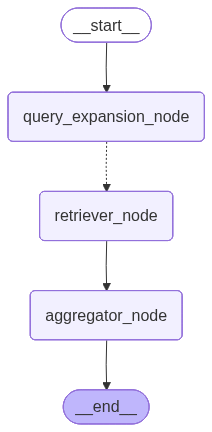

In [10]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_conditional_edges("query_expansion_node", parallel_retriever, ["retriever_node"])
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display_graph(graph)


In [11]:
query = "The hydraulic pump on the HX-350 is losing efficiency and I'm also seeing a valve overhaul scheduled."
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)


In [12]:
print(result["answer"])


Regarding the HX-350, the hydraulic pump loss of efficiency is likely related to internal wear causing the volumetric efficiency to decline, similar to issues observed in other machines such as IH-300 and AS-600. This situation often necessitates cleaning, recalibration, or replacement of components to restore functionality. Additionally, the valve overhaul scheduled for the HX-350 corresponds to the PRV-302 relief valve maintenance. Recent records from 2024-08-28 show the valve venting to tank due to a set point measured at 7 bar (spec 250 bar), indicating the component is reaching the end of its expected service life, with replacement or adjustment overdue. This valve fault was addressed with an adjustment and function check, but continued monitoring and eventual replacement are recommended. In summary, the hydraulic pump inefficiency and valve overhaul on the HX-350 align with documented wear and service life end of critical components, requiring maintenance actions such as cleaning

## User Intent Router 

In [29]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [30]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a maintenance assistant that answers questions about equipment interventions and failure history.

    ## Instructions

    - Determine whether the question is about machines characteristics, components, failures, maintenance interventions or troubleshooting.
    - Questions about fault codes, symptoms, repair history, root causes, scheduled maintenance, and component replacements are relevant.
    - Questions about HR policies, personal advice, or unrelated topics are not relevant.

    ## Examples

    Question: "What caused the hydraulic pump failure on HX-350?"
    Relevant: yes

    Question: "What's the weather like today?"
    Relevant: no - not related to maintenance

    Question: "Can you help me write an email?"
    Relevant: no - not related to maintenance

    Question: "Show me all bearing failures on CB-200 last year"
    Relevant: yes

    Question: "What's the company vacation policy?"
    Relevant: no - about HR policy, not equipment maintenance

    <question>
    {{ query }}
    </question>
    """

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=IntentRouterResponse
    )
 
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [31]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

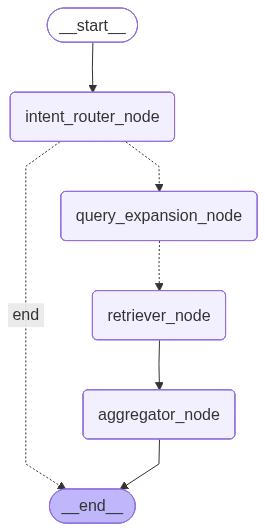

In [32]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node", 
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)

workflow.add_conditional_edges("query_expansion_node", parallel_retriever, ["retriever_node"])
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display_graph(graph)


In [33]:
query = "What's the last contract we have in the db"
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)
print(result['answer'])

The question "What's the last contract we have in the db" is not related to machines characteristics, components, failures, maintenance interventions, or troubleshooting. It is about contract information, which is not relevant to equipment maintenance.


In [34]:
query = "The hydraulic pump on the HX-350 is losing efficiency and I'm also seeing a valve overhaul scheduled."
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)
print(result['answer'])

ValidationError: 2 validation errors for State
expanded_query.0
  Input should be a valid dictionary or instance of ExpandedQuery [type=model_type, input_value=ExpandedQuery(query='Hydr...oss on HX-350', top_k=4), input_type=ExpandedQuery]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type
expanded_query.1
  Input should be a valid dictionary or instance of ExpandedQuery [type=model_type, input_value=ExpandedQuery(query='HX-3...ance schedule', top_k=3), input_type=ExpandedQuery]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type